# PART A – **ANN FOR REGRESSION**

# Import libraries

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error
print('NAME:    AKHIL C\nROLL NO: 24BAD007')

NAME:    AKHIL C
ROLL NO: 24BAD007


# Load California Housing dataset

In [2]:
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()

In [3]:
# Features (Input)
X = housing.data

# Target (Output)
y = housing.target

# Convert to a Pandas DataFrame
df = pd.DataFrame(X, columns=housing.feature_names)

# Add the target column
df["HouseValue"] = y

# Display the first 5 rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HouseValue
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# Split into training and testing sets. 

In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardize the features

In [5]:
# Create the StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test = scaler.transform(X_test)

# Build ANN model

In [7]:
# Create the ANN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(1)
])

c:\Users\Akhil\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile the model

In [8]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Train the model

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.8455 - mae: 0.6362 - val_loss: 0.4742 - val_mae: 0.4886
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4066 - mae: 0.4549 - val_loss: 0.4091 - val_mae: 0.4495
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3742 - mae: 0.4352 - val_loss: 0.3912 - val_mae: 0.4416
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3583 - mae: 0.4227 - val_loss: 0.3780 - val_mae: 0.4286
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3465 - mae: 0.4150 - val_loss: 0.3608 - val_mae: 0.4226
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3383 - mae: 0.4084 - val_loss: 0.3526 - val_mae: 0.4206
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3273 - mae: 0.4001 - val_loss: 0.3449 - val_mae: 0.4051
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3189 - mae: 0.3944 - val_loss: 0.3463 - val_mae: 0.4055
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - lo

# Predict house prices

In [10]:
# Predict house prices for the test data
y_pred = model.predict(X_test)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step


In [11]:
print('Actual prices: ')
y_pred=y_pred.flatten()
print(y_test[:5])
print('\npredicted prices: ')
print(y_pred[:5])

Actual prices: 
[0.477   0.458   5.00001 2.186   2.78   ]

predicted prices: 
[0.4861889 1.134195  4.838734  2.723758  3.006796 ]


# Visualizations

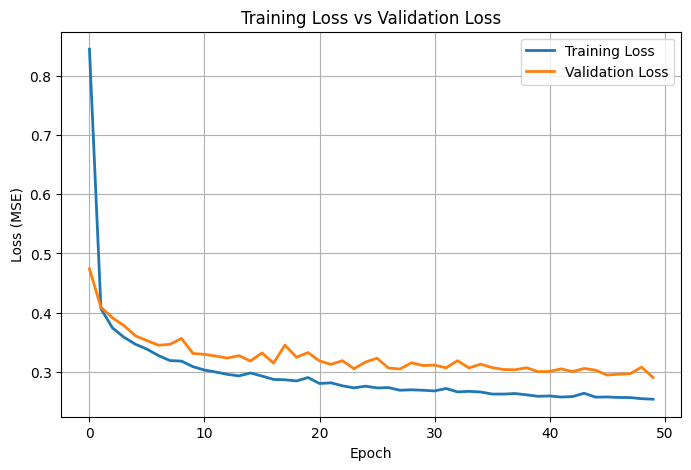

In [ ]:
# Plot Training Loss vs Validation Loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate RMSE,MSE,MAE

In [18]:
# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print("Mean Squared Error (MSE):", round(mse,2))
print("Mean Absolute Error (MAE):", round(mae,2))
print("Root Mean Squared Error (RMSE):", round(rmse,2))

Mean Squared Error (MSE): 0.29
Mean Absolute Error (MAE): 0.37
Root Mean Squared Error (RMSE): 0.53
